# Deceptive Opinion Spam Corpus

### Context

This corpus consists of truthful and deceptive hotel reviews of 20 Chicago hotels. The data is described in two papers according to the sentiment of the review. In particular, we discuss positive sentiment reviews in [1] and negative sentiment reviews in [2].
While we have tried to maintain consistent data preprocessing procedures across the data, there are differences which are explained in more detail in the associated papers. Please see those papers for specific details.

### Content

This corpus contains:

- 400 truthful positive reviews from TripAdvisor (described in [1])
- 400 deceptive positive reviews from Mechanical Turk (described in [1])
- 400 truthful negative reviews from Expedia, Hotels.com, Orbitz, Priceline, TripAdvisor and Yelp (described in [2])
- 400 deceptive negative reviews from Mechanical Turk (described in [2])

Each of the above datasets consist of 20 reviews for each of the 20 most popular Chicago hotels (see [1] for more details). The files are named according to the following conventions:
Directories prefixed with fold correspond to a single fold from the cross-validation experiments reported in [1] and [2].

### References

[1] M. Ott, Y. Choi, C. Cardie, and J.T. Hancock. 2011. Finding Deceptive Opinion Spam by Any Stretch of the Imagination. In Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies.

[2] M. Ott, C. Cardie, and J.T. Hancock. 2013. Negative Deceptive Opinion Spam. In Proceedings of the 2013 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies.


In [ ]:
import re
import nltk
import string

import numpy as np
import pandas as pd

from pathlib import Path
from thinc.api import Config


from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jmanuelc87/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jmanuelc87/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Read the dataset

In [2]:
df = pd.read_csv(
    "../data/deceptive_opinions/deceptive-opinion.csv",
    usecols=["deceptive", "polarity", "text"],
)
df.head()

,deceptive,polarity,text
0,truthful,positive,We stayed for a one night getaway with family ...
1,truthful,positive,Triple A rate with upgrade to view room was le...
2,truthful,positive,This comes a little late as I'm finally catchi...
3,truthful,positive,The Omni Chicago really delivers on all fronts...
4,truthful,positive,I asked for a high floor away from the elevato...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   deceptive  1600 non-null   str  
 1   polarity   1600 non-null   str  
 2   text       1600 non-null   str  
dtypes: str(3)
memory usage: 37.6 KB


In [4]:
df["word_count"] = df["text"].str.split().str.len()
df['word_count'].describe()

count    1600.000000
mean      148.775000
std        87.335984
min        25.000000
25%        88.000000
50%       128.000000
75%       182.250000
max       784.000000
Name: word_count, dtype: float64

## Lower Case

In [5]:
df["text"] = df["text"].apply(lambda x: x.lower())

df.head()

,deceptive,polarity,text,word_count
0,truthful,positive,we stayed for a one night getaway with family ...,105
1,truthful,positive,triple a rate with upgrade to view room was le...,45
2,truthful,positive,this comes a little late as i'm finally catchi...,207
3,truthful,positive,the omni chicago really delivers on all fronts...,127
4,truthful,positive,i asked for a high floor away from the elevato...,72


## Tokenize

The tokenizer splits string into sequences of smaller pieces of text called tokens


In [6]:
tokenizer = nltk.tokenize.WordPunctTokenizer()

df["text_pp"] = df["text"].apply(lambda x: tokenizer.tokenize(x))

df.head()

,deceptive,polarity,text,word_count,text_pp
0,truthful,positive,we stayed for a one night getaway with family ...,105,"[we, stayed, for, a, one, night, getaway, with..."
1,truthful,positive,triple a rate with upgrade to view room was le...,45,"[triple, a, rate, with, upgrade, to, view, roo..."
2,truthful,positive,this comes a little late as i'm finally catchi...,207,"[this, comes, a, little, late, as, i, ', m, fi..."
3,truthful,positive,the omni chicago really delivers on all fronts...,127,"[the, omni, chicago, really, delivers, on, all..."
4,truthful,positive,i asked for a high floor away from the elevato...,72,"[i, asked, for, a, high, floor, away, from, th..."


## Stop Words

Removal of stop words

In [7]:
df["text_pp"] = df["text_pp"].apply(
    lambda x: [token for token in x if token not in stopwords.words("english")]
)

df.head()

,deceptive,polarity,text,word_count,text_pp
0,truthful,positive,we stayed for a one night getaway with family ...,105,"[stayed, one, night, getaway, family, thursday..."
1,truthful,positive,triple a rate with upgrade to view room was le...,45,"[triple, rate, upgrade, view, room, less, $, 2..."
2,truthful,positive,this comes a little late as i'm finally catchi...,207,"[comes, little, late, ', finally, catching, re..."
3,truthful,positive,the omni chicago really delivers on all fronts...,127,"[omni, chicago, really, delivers, fronts, ,, s..."
4,truthful,positive,i asked for a high floor away from the elevato...,72,"[asked, high, floor, away, elevator, got, ., r..."


## Remove punctiation

Remove signs such as period, colon, semicolon, etc.

In [8]:
df["text_pp"] = df["text_pp"].apply(
    lambda x: [token for token in x if token not in string.punctuation]
)

df.head()

,deceptive,polarity,text,word_count,text_pp
0,truthful,positive,we stayed for a one night getaway with family ...,105,"[stayed, one, night, getaway, family, thursday..."
1,truthful,positive,triple a rate with upgrade to view room was le...,45,"[triple, rate, upgrade, view, room, less, 200,..."
2,truthful,positive,this comes a little late as i'm finally catchi...,207,"[comes, little, late, finally, catching, revie..."
3,truthful,positive,the omni chicago really delivers on all fronts...,127,"[omni, chicago, really, delivers, fronts, spac..."
4,truthful,positive,i asked for a high floor away from the elevato...,72,"[asked, high, floor, away, elevator, got, room..."


## Lemmatizer

Extraction of the root of the word

In [9]:
lemmatizer = nltk.stem.WordNetLemmatizer()

df["text_pp"] = df["text_pp"].apply(
    lambda x: [lemmatizer.lemmatize(token, "v") for token in x]
)

df.head()

,deceptive,polarity,text,word_count,text_pp
0,truthful,positive,we stayed for a one night getaway with family ...,105,"[stay, one, night, getaway, family, thursday, ..."
1,truthful,positive,triple a rate with upgrade to view room was le...,45,"[triple, rate, upgrade, view, room, less, 200,..."
2,truthful,positive,this comes a little late as i'm finally catchi...,207,"[come, little, late, finally, catch, review, p..."
3,truthful,positive,the omni chicago really delivers on all fronts...,127,"[omni, chicago, really, deliver, front, spacio..."
4,truthful,positive,i asked for a high floor away from the elevato...,72,"[ask, high, floor, away, elevator, get, room, ..."


## Vectorizacion del texto y One hot

In [ ]:
vectorizer = TfidfVectorizer(min_df=2, lowercase=False)
one_hot = OneHotEncoder(drop="if_binary", sparse_output=False)

X, y = vectorizer.fit_transform(df["text_pp"].apply(lambda x: " ".join(x))), df["deceptive"]
X.shape, y.shape

((1600, 4084), (1600,))

In [11]:
# Show features
feature_names = vectorizer.get_feature_names_out()
pd.DataFrame(X.todense(), index=df.index, columns=feature_names)

,00,000,00am,03,06,09,10,100,10pm,10th,...,yogurt,york,young,younger,yuck,yummy,yup,zest,zone,zoo
0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.114766,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1596,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1597,0.12973,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1598,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Train and Test datasets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=True,
    random_state=8,
    stratify=df[["deceptive", "polarity"]],
)

print("Registros en Train:", X_train.shape, y_train.shape)
print("Registros en Test:", X_test.shape, y_test.shape)

Registros en Train: (1280, 4084) (1280,)
Registros en Test: (320, 4084) (320,)


## Logistic Regression without penalization

In [13]:
m1 = LogisticRegression(
    penalty=None, random_state=42, max_iter=1500, tol=1e-4, solver="sag"
).fit(X_train, y_train)

/Users/jmanuelc87/Documents/Projects/bourbaki-track-ciencia-datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [14]:
y_pred = m1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   deceptive       0.88      0.86      0.87       160
    truthful       0.87      0.89      0.88       160

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.87       320
weighted avg       0.88      0.88      0.87       320



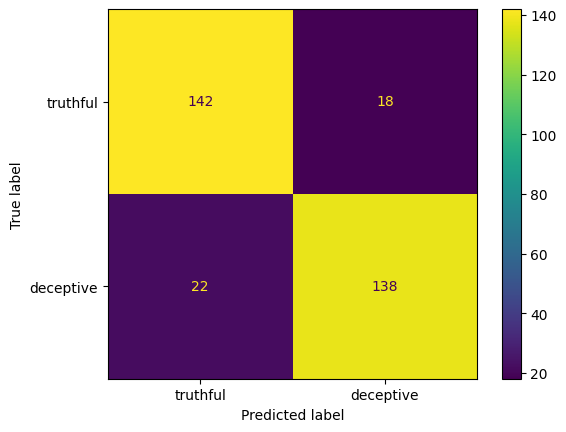

In [15]:
ConfusionMatrixDisplay.from_estimator(m1, X_test, y_test, labels=df["deceptive"].unique())

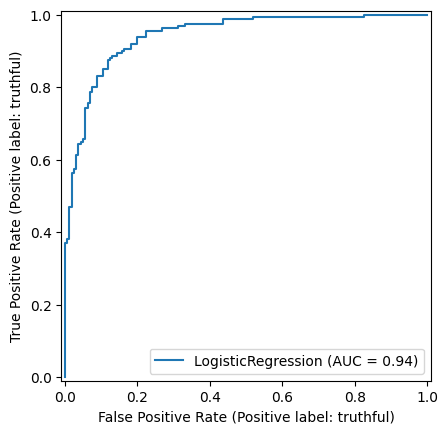

In [16]:
RocCurveDisplay.from_estimator(m1, X_test, y_test)

In [ ]:
fpr, tpr, thresholds = roc_curve(
    pd.get_dummies(y_test, drop_first=True), m1.predict_proba(X_test)[:, 0]
)